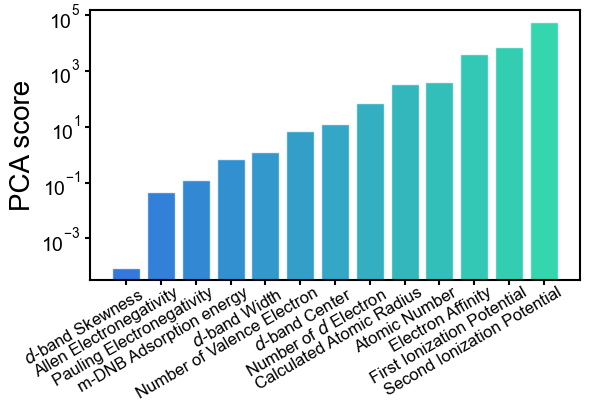

In [5]:
# region: import
import os, sys, yaml
import ipynbname
import numpy, copy, pandas
import matplotlib.pyplot
import pyexp
import pyexp.api.raman
import matplotlib.patches
import sys
path_folder_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if path_folder_root not in sys.path: sys.path.append(path_folder_root)
from conf.conf import dict_conf_cata_default
%matplotlib widget
# endregion

# region: conf
# header 
str_yaml = open('./dats/dict_header.yaml').read()
dict_header = yaml.load(str_yaml, Loader=yaml.FullLoader)
# endregion

# region: read data
frame = pandas.read_table('./dats/dat_pca.txt', header=None, sep=r'\s+')
list_name_var = frame.to_numpy()[:, 0].tolist()
list_val_var = frame.to_numpy()[:, 1].tolist()
# endregion

# region: fig
fig, ax = pyexp.initial_fig_ax(figsize=[6, 4], bottom=1.2)
ax.set_yscale('log')  
ax.set_ylabel('PCA score', fontsize=pyexp.dict_conf_fontsize['label'])
# endregion

# region: plot
# bar
cmap = matplotlib.pyplot.cm.winter
for ii, (name_var, val_var) in \
    enumerate(zip(list_name_var, list_val_var)):
    scale_color = 0.3 + 0.5*((ii+1)/len(list_name_var))
    pyexp.plot_bar(
        ax=ax, array_xx=[ii], array_yy=[val_var], 
        conf_bar={'facecolor': cmap(scale_color), })
# xticklabel
ax.set_xticks(numpy.arange(len(list_name_var)))
ax.set_xticklabels(
    [dict_header[name_var]['label'] for name_var in list_name_var], 
    fontsize=12, )
for label in ax.get_xticklabels():
    label.set_rotation(30)
    label.set_horizontalalignment('right')
    offset = matplotlib.transforms.ScaledTranslation(0.2, 0.05, ax.figure.dpi_scale_trans)
    label.set_transform(label.get_transform() + offset)
# endregion


# region: save
pyexp.save_fig(fig=fig, )
# endregion
